# Multi-Layer Perceptron from Scratch

[Examples adopted from this notebook](https://colab.research.google.com/drive/1HzVYVikFmp2S_ks0nbkDcuwoTZBdyUbr?usp=sharing)

We'll build up a Multi-Layer Perceptron (MLP) in three steps:

1. **Manual computation** — implement a layer by hand using PyTorch tensors.
2. **`nn.Linear`** — see how PyTorch packages perform the same math into a reusable layer.
3. **MNIST** — assemble the layers into a small network and run a forward pass on a hand-written digit.

A neural network layer transforms its inputs by multiplying them with a weight matrix, adding a bias, and applying an activation. Doing this as **one matrix multiplication** — instead of looping over neurons — is what makes deep learning fast.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/vectorization.png)

In [6]:
import torch

In [7]:
# Weight matrix: 2 input features → 3 neurons
WeightMatrix = torch.tensor([
    [1., 2.],
    [3., 4.],
    [5., 6.]
])

# Input: 2 features, batch size of 1
Input_1 = torch.tensor([
    [0.15],
    [0.25]
])

WeightMatrix, Input_1

(tensor([[1., 2.],
         [3., 4.],
         [5., 6.]]),
 tensor([[0.1500],
         [0.2500]]))

In [9]:
# One matrix multiplication = weighted sum for every neuron at once
torch.matmul(WeightMatrix, Input_1)

tensor([[0.6500],
        [1.4500],
        [2.2500]])

In [10]:
# Same operation, but now with a batch of 3 samples (2 features × 3 samples)
Input_1 = torch.tensor([
    [0.15, 0.3, 0.5],
    [0.25, 0.4, 0.6]
])
torch.matmul(WeightMatrix, Input_1)

tensor([[0.6500, 1.1000, 1.7000],
        [1.4500, 2.5000, 3.9000],
        [2.2500, 3.9000, 6.1000]])

## Reshaping the input

In practice it's more natural to put each sample on its own **row** rather than its own column. To keep the multiplication valid, we then need to **transpose** the weight matrix.

In [11]:
# Batch of 3 samples, each with 2 features → shape (3, 2)
Input_2 = torch.tensor([
    [0.15, 0.25],
    [0.3, 0.4],
    [0.5, 0.6]
])

Input_2.shape

torch.Size([3, 2])

In [12]:
# This would fail: matmul requires the inner dimensions to match.
# WeightMatrix is (3, 2) and Input_2 is (3, 2) — not compatible.
# torch.matmul(WeightMatrix, Input_2)

In [13]:
WeightMatrix.T

tensor([[1., 3., 5.],
        [2., 4., 6.]])

In [14]:
torch.matmul(Input_2, WeightMatrix.T)

tensor([[0.6500, 1.4500, 2.2500],
        [1.1000, 2.5000, 3.9000],
        [1.7000, 3.9000, 6.1000]])

## Adding a bias

Each neuron also has its own **bias**, added after the weighted sum. With one bias per neuron, the bias vector has length equal to the number of outputs.

In [15]:
bias = torch.tensor([1.1, -2.1, -3.1])

In [16]:
torch.matmul(Input_2, WeightMatrix.T) + bias

tensor([[ 1.7500, -0.6500, -0.8500],
        [ 2.2000,  0.4000,  0.8000],
        [ 2.8000,  1.8000,  3.0000]])

## Adding an activation function

An activation introduces **non-linearity** — without it, stacking layers would just collapse into one big linear function. We'll use **ReLU** (Rectified Linear Unit):

$$\text{ReLU}(x) = \max(0, x)$$

It simply replaces negative values with zero.

In [18]:
x = torch.matmul(Input_2, WeightMatrix.T) + bias

# ReLU: clamp every value to be at least 0
torch.clamp(x, min=0)

tensor([[1.7500, 0.0000, 0.0000],
        [2.2000, 0.4000, 0.8000],
        [2.8000, 1.8000, 3.0000]])

# Using `nn.Linear`

We've now seen the math of a layer up close. Doing it by hand every time gets tedious — and we still need to track parameters, gradients, and devices. PyTorch's **`nn.Linear`** wraps the weight matrix, bias, and matmul into a single reusable building block.

![picture](https://upload.wikimedia.org/wikipedia/commons/9/96/Pytorch_logo.png?20211003060202)

In [19]:
import torch
from torch import nn

### The Linear layer

`nn.Linear(in_features, out_features)` creates a layer with a randomly-initialised weight matrix and a bias vector. Calling the layer performs exactly the operation we just did by hand:

$$y = x\,W^\top + b$$

To verify, we'll override its random weights with the same values we used above and confirm we get the same numbers.

In [20]:
layer = nn.Linear(2,3)

In [21]:
layer.bias

Parameter containing:
tensor([-0.5021,  0.4000, -0.7000], requires_grad=True)

In [23]:
layer.weight.data = torch.tensor([
    [1., 2.],
    [3., 4.],
    [5., 6.]
])

layer.weight


Parameter containing:
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]], requires_grad=True)

In [24]:
layer.bias.data = torch.tensor([1.1, -2.1, -3.1])


In [25]:
Input = torch.tensor([
    [0.15, 0.25],
    [0.3, 0.4],
    [0.5, 0.6]
])

Input

tensor([[0.1500, 0.2500],
        [0.3000, 0.4000],
        [0.5000, 0.6000]])

In [26]:
layer(Input)

tensor([[ 1.7500, -0.6500, -0.8500],
        [ 2.2000,  0.4000,  0.8000],
        [ 2.8000,  1.8000,  3.0000]], grad_fn=<AddmmBackward0>)

In [28]:
import torch.nn.functional as F

x= layer(Input)
F.relu(x)

tensor([[1.7500, 0.0000, 0.0000],
        [2.2000, 0.4000, 0.8000],
        [2.8000, 1.8000, 3.0000]], grad_fn=<ReluBackward0>)

# Recognising digits

Time to build a real classifier. We'll use **MNIST** — a dataset of 28×28 grayscale images of hand-written digits (0–9), the canonical "Hello World" of deep learning.

The plan:

1. Load and inspect a single image.
2. Convert it to a tensor.
3. Define an MLP and run a forward pass to predict the digit.

In [1]:
# Download and extract the dataset

!wget https://github.com/kyuz0/mnist-png/raw/main/mnist.tgz
!tar xzf mnist.tgz

--2026-04-29 14:20:32--  https://github.com/kyuz0/mnist-png/raw/main/mnist.tgz
Resolving github.com (github.com)... 20.207.73.82
Connecting to github.com (github.com)|20.207.73.82|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/kyuz0/mnist-png/main/mnist.tgz [following]
--2026-04-29 14:20:33--  https://raw.githubusercontent.com/kyuz0/mnist-png/main/mnist.tgz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18294568 (17M) [application/octet-stream]
Saving to: ‘mnist.tgz’

mnist.tgz           100%[===================>]  17.45M  16.6MB/s    in 1.1s    

2026-04-29 14:20:35 (16.6 MB/s) - ‘mnist.tgz’ saved [18294568/18294568]



In [29]:
from PIL import Image
import torchvision.transforms as transforms


In [30]:
image_path = 'mnist/training/0/1.png'
image = Image.open(image_path)
image

## From image to tensor

A neural network can't read a PNG directly — we need to convert the image into a tensor of pixel intensities. `transforms.ToTensor()` does this and also rescales each pixel from `0..255` (8-bit greyscale) to a float in `0.0..1.0`.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/input.png)

In [31]:
# Define the transformation
transform = transforms.Compose([
    transforms.ToTensor()
])

# Apply the transformation to the image
tensor_image = transform(image).squeeze(0)

# Check the shape of the tensor
print(tensor_image.shape)

tensor_image[20][22]

torch.Size([28, 28])


tensor(1.)

In [32]:
tensor_image

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000

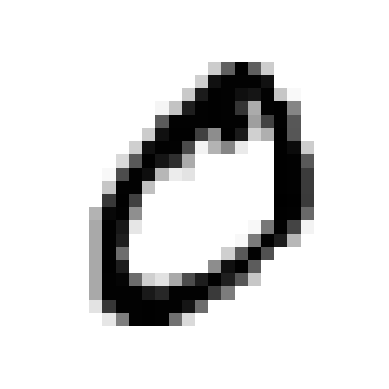

In [33]:
import matplotlib.pyplot as plt

def imshow(tensor_image):
    plt.imshow(tensor_image, cmap='gray')
    plt.axis('off')
    plt.show()

# Display the tensor image using matplotlib
imshow(tensor_image)

## Defining the model

Our MLP has three fully-connected layers:

| Layer | Inputs | Outputs | Activation |
|-------|--------|---------|------------|
| 1 | 28 × 28 = 784 | 100 | ReLU |
| 2 | 100 | 150 | ReLU |
| 3 (output) | 150 | 10 | none — raw **logits** |

The final layer outputs one number per digit class. We **don't** apply an activation here: the loss function (during training) and `softmax` (for inference) will handle that.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/mpl.png)

In [34]:
import torch.nn.functional as F

class MNISTNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.Layer1 = nn.Linear(28*28, 100)
    self.Layer2 = nn.Linear(100, 150)
    self.Layer3 = nn.Linear(150, 10)

  def forward(self, x):
    x =  F.relu(self.Layer1(x))
    x =  F.relu(self.Layer2(x))
    x =  self.Layer3(x)
    return x

In [36]:
model = MNISTNet()
model

MNISTNet(
  (Layer1): Linear(in_features=784, out_features=100, bias=True)
  (Layer2): Linear(in_features=100, out_features=150, bias=True)
  (Layer3): Linear(in_features=150, out_features=10, bias=True)
)

In [37]:
for name, param in model.named_parameters():
    print(f"Name: {name}")
    print(f"Value: {param.data}")
    print("------")

Name: Layer1.weight
Value: tensor([[-0.0130,  0.0062, -0.0116,  ..., -0.0071,  0.0284, -0.0073],
        [ 0.0065,  0.0017, -0.0166,  ...,  0.0163, -0.0171,  0.0046],
        [-0.0178,  0.0044,  0.0287,  ...,  0.0008, -0.0054, -0.0035],
        ...,
        [-0.0230,  0.0127,  0.0197,  ..., -0.0125, -0.0210, -0.0077],
        [-0.0311, -0.0332,  0.0329,  ...,  0.0222,  0.0284,  0.0253],
        [-0.0119,  0.0317, -0.0034,  ...,  0.0352, -0.0016, -0.0185]])
------
Name: Layer1.bias
Value: tensor([ 0.0218, -0.0136, -0.0055, -0.0317,  0.0007, -0.0095,  0.0170,  0.0321,
         0.0242,  0.0198, -0.0012, -0.0275,  0.0147, -0.0086,  0.0001,  0.0154,
         0.0138,  0.0351,  0.0313,  0.0061,  0.0348, -0.0079,  0.0292,  0.0171,
         0.0309,  0.0080,  0.0193, -0.0015,  0.0118,  0.0289, -0.0024,  0.0098,
        -0.0293,  0.0053, -0.0276,  0.0157,  0.0094,  0.0106,  0.0243, -0.0036,
        -0.0339, -0.0140, -0.0279,  0.0229, -0.0020,  0.0296, -0.0268,  0.0261,
         0.0078,  0.0072, -

In [38]:
model.Layer3.weight.shape

torch.Size([10, 150])

## Forward pass

To run a single image through the network we need to:

1. **Flatten** the 28×28 image into a 784-vector.
2. **Add a batch dimension** → shape `(1, 784)` (the model always expects a batch).
3. Pass it through the model to get **10 logits** — one per digit.
4. Apply **softmax** to turn the logits into probabilities that sum to 1.

The model is untrained, so the probabilities will all be roughly `0.1`.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/multi-class.png)

In [39]:
tensor_image.reshape(1,28*28)

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0

In [40]:
y_hat = model(tensor_image.reshape(1,28*28))

In [ ]:
y_hat

tensor([[ 0.1321, -0.0515,  0.1063, -0.2405, -0.0755,  0.0825, -0.0529,  0.1211,
         -0.0676, -0.0296]], grad_fn=<AddmmBackward0>)

In [41]:
F.softmax(y_hat, dim=1)

tensor([[0.1092, 0.0854, 0.1110, 0.0923, 0.1000, 0.0990, 0.0962, 0.1062, 0.1056,
         0.0952]], grad_fn=<SoftmaxBackward0>)

# Running on a GPU

GPUs are dramatically faster than CPUs at the matrix operations we just saw. In PyTorch, moving a model and its inputs to the GPU is a one-line change with `.to(DEVICE)`.

**Important:** the model and its inputs must live on the **same device**, otherwise PyTorch will raise an error.

![picture](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/2.2%20-%20Lab%20-%20Multi-Layer%20Perceptron%20and%20MNIST%20/gpus.png)

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda', index=0)

In [ ]:
model.to(DEVICE)

y_hat = model(tensor_image.reshape(1,28*28).to(DEVICE))

In [ ]:
y_hat

tensor([[ 0.1321, -0.0515,  0.1063, -0.2405, -0.0755,  0.0825, -0.0529,  0.1211,
         -0.0676, -0.0296]], device='cuda:0', grad_fn=<AddmmBackward0>)